# Policy-Frame-Titelannotation: MFC-LLM-Konsens und Ground-Truth-Abgleich

Dieses Notebook verarbeitet drei unabhängige LLM-Annotationen des MFC-Datensatzes und gleicht den daraus gebildeten Konsens mit `mfc_ground_truth_full.csv` als Goldstandard ab.

## Workflow
1. Drei LLM-Annotationen werden eingelesen.
2. Die LLM-Codes `2` werden nach der Validierung zu `1` umcodiert; die Ground Truth bleibt unverändert binär (`0/1`).
3. Ein Frame gilt bei **mindestens 2 von 3 positiven Stimmen** als Konsens. Sowohl `2/3` als auch `3/3` werden übernommen.
4. Die gemeinsame Artikel-ID ist in allen vier Dateien `Filename`. Die Quelldateien werden nicht verändert; intern wird `Filename` als `article_id` verwendet.
5. Die exakten `Filename`-Mengen aller vier Dateien werden verglichen. Bei einer Abweichung bricht das Notebook mit einem Fehler ab.
6. Der LLM-Konsens wird mit `mfc_ground_truth_full.csv` abgeglichen. Ein konsensuell erkannter Frame bleibt nur erhalten, wenn er auch in der Ground Truth positiv annotiert ist.
7. Konsensstärke (`2/3` oder `3/3`) und Einzelstimmen werden im Konsensprotokoll dokumentiert.
8. Alle erzeugten Dateien werden im Unterordner `mfc_konsens_output` abgelegt.


In [1]:
from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

print("Pandas:", pd.__version__)


Pandas: 2.3.3


## 1. Konfiguration

Die Eingabedateien werden relativ zum aktuellen Notebook-Arbeitsverzeichnis eingelesen. Das Ausgabeziel wird als `mfc_konsens_output` relativ dazu angelegt.

> Hinweis: `Path.cwd()` entspricht dem Notebook-Verzeichnis, sofern das Notebook aus seinem Verzeichnis heraus ausgeführt wird. Die Quelldateien werden nicht verändert.


In [2]:
# ---------- Pfade ----------
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "mfc_konsens_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LLM_FILES = [
    "headlines_dataset_full_LLM_annotiert_claude_Sonnet5.csv",
    "headlines_dataset_full_LLM_annotiert_Gemini_Flash3.6.csv",
    "headlines_dataset_full_LLM_annotiert_ChatGPT_5.6Luna.csv",
]
GROUND_TRUTH_FILE = "ground_truth_full.csv"

# ---------- Schlüssel / Metadaten ----------
# Die Originalspalten bleiben unverändert. Intern wird Filename auf article_id abgebildet.
ID_COLUMN = "article_id"
SOURCE_ID_COLUMN = "Filename"
TITLE_COLUMN = "Headline_GER"
LANGUAGE_COLUMN = "Language"

POLICY_FRAME_COLUMNS = [
    "Economic",
    "Capacity and resources",
    "Morality",
    "Fairness and equality",
    "Legality, constitutionality and jurisprudence",
    "Policy prescription and evaluation",
    "Crime and punishment",
    "Security and defense",
    "Health and safety",
    "Quality of life",
    "Cultural identity",
    "Public opinion",
    "Political",
    "External regulation and reputation",
]
FRAME_COLUMNS = POLICY_FRAME_COLUMNS

# ---------- Kodierung / Konsens ----------
LLM_VALID_VALUES = {0, 1, 2}
GROUND_TRUTH_VALID_VALUES = {0, 1}
VALUE_RECODE_MAP = {2: 1}
MIN_CONSENSUS_VOTES = 2
LLM_COUNT = 3
ACCEPTED_VOTE_COUNTS = {2, 3}

# ---------- Modellnamen ----------
LLM_NAMES = [
    "Haiku 4.5",
    "MistralAI GLM-5-2",
    "GPT-5.6 Luna",
]

# ---------- Ausgabedateien ----------
OUTPUT_FILES = {
    "consensus": OUTPUT_DIR / "mfc_01_llm_konsens.xlsx",
    "protocol": OUTPUT_DIR / "mfc_02_konsensprotokoll.xlsx",
    "final": OUTPUT_DIR / "mfc_03_finale_titelannotationen.xlsx",
    "removal": OUTPUT_DIR / "mfc_04_streichungsprotokoll.xlsx",
    "statistics": OUTPUT_DIR / "mfc_05_frame_statistik.xlsx",
    "plot": OUTPUT_DIR / "mfc_05_frame_statistik.png",
    "summary": OUTPUT_DIR / "mfc_06_zentrale_auswertung.txt",
}

llm_paths = [BASE_DIR / name for name in LLM_FILES]
ground_truth_path = BASE_DIR / GROUND_TRUTH_FILE

if len(LLM_FILES) != LLM_COUNT or len(LLM_NAMES) != LLM_COUNT:
    raise ValueError("Anzahl der LLM-Dateien und Modellnamen muss exakt 3 betragen.")

print("Basisverzeichnis:", BASE_DIR)
print("Ausgabeordner:", OUTPUT_DIR)


Basisverzeichnis: /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_additional_dataset/5_konsens_bildung/semeval_2023
Ausgabeordner: /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_additional_dataset/5_konsens_bildung/semeval_2023/mfc_konsens_output


## 2. Einlesen und Validierung

Die CSV-Dateien werden robust mit einem CSV-Parser eingelesen. Der Trenner wird zwischen `;` und `,` automatisch aus der Kopfzeile erkannt. Dadurch funktioniert das Notebook sowohl mit semikolon- als auch mit komma-getrennten MFC-CSV-Dateien; korrekt quotierte mehrzeilige Felder bleiben erhalten.

Die Validierung bricht bewusst ab bei fehlenden Dateien, fehlenden Pflichtspalten, leeren oder doppelten IDs, unbekannten Frame-Codes oder inkonsistenten ID-Mengen.


In [3]:
import csv

def detect_csv_separator(path):
    """Ermittelt den CSV-Trenner anhand der ersten nichtleeren Zeile."""
    with path.open("r", encoding="utf-8-sig", newline="") as handle:
        header = handle.readline().strip("\\r\\n")

    candidates = {";": header.count(";"), ",": header.count(",")}
    separator = max(candidates, key=candidates.get)
    if candidates[separator] == 0:
        raise ValueError(
            f"{path.name}: Kein unterstützter CSV-Trenner (';' oder ',') in der Kopfzeile gefunden."
        )
    return separator


def read_csv_table(path):
    separator = detect_csv_separator(path)
    return pd.read_csv(
        path,
        sep=separator,
        quotechar='"',
        encoding="utf-8-sig",
        dtype={SOURCE_ID_COLUMN: "string"},
        keep_default_na=False,
    )


def prepare_frame_codes(df, valid_values, source_name, recode_values=None):
    allowed = {int(v) for v in valid_values}
    recode_values = recode_values or {}
    result = df.copy()

    for frame in FRAME_COLUMNS:
        numeric = pd.to_numeric(result[frame], errors="raise")
        observed = set(numeric.astype(int).unique())
        invalid = sorted(observed - allowed)
        if invalid:
            raise ValueError(
                f"{source_name}: ungültige Werte in '{frame}': {invalid}. "
                f"Erlaubt: {sorted(allowed)}"
            )
        result[frame] = numeric.astype(int)
        for old, new in recode_values.items():
            result[frame] = result[frame].replace(old, new)

    return result


def validate_table(df, source_name, valid_values, recode_values=None):
    required = {SOURCE_ID_COLUMN, *FRAME_COLUMNS}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f"{source_name}: fehlende Pflichtspalten: {missing}")

    result = df.copy()
    result[SOURCE_ID_COLUMN] = result[SOURCE_ID_COLUMN].astype("string").str.strip()

    if (result[SOURCE_ID_COLUMN] == "").any():
        raise ValueError(f"{source_name}: mindestens eine leere Filename-ID.")

    duplicates = result.loc[
        result[SOURCE_ID_COLUMN].duplicated(keep=False), SOURCE_ID_COLUMN
    ].unique().tolist()
    if duplicates:
        raise ValueError(f"{source_name}: doppelte Filename-IDs: {duplicates[:20]}")

    for frame in FRAME_COLUMNS:
        if result[frame].isna().any():
            raise ValueError(f"{source_name}: fehlende Werte in '{frame}'.")

    result = prepare_frame_codes(
        result,
        valid_values,
        source_name,
        recode_values=recode_values,
    )
    return result.rename(columns={SOURCE_ID_COLUMN: ID_COLUMN})


missing_files = [str(p) for p in [*llm_paths, ground_truth_path] if not p.exists()]
if missing_files:
    raise FileNotFoundError(
        "Folgende Eingabedateien fehlen:\\n" + "\\n".join(missing_files)
    )

llm_raw = [read_csv_table(p) for p in llm_paths]
ground_truth_raw = read_csv_table(ground_truth_path)

# Für alle drei LLM-Dateien: 2 -> 1.
llm_data = [
    validate_table(
        df,
        path.name,
        LLM_VALID_VALUES,
        recode_values=VALUE_RECODE_MAP,
    )
    for df, path in zip(llm_raw, llm_paths)
]

# Ground Truth bleibt binär und wird nicht umcodiert.
ground_truth = validate_table(
    ground_truth_raw,
    ground_truth_path.name,
    GROUND_TRUTH_VALID_VALUES,
    recode_values=None,
)

print("Datei- und Schema-Prüfung erfolgreich.")
for path, df in zip(llm_paths, llm_data):
    print(f"LLM  {path.name}: {len(df)} Artikel")
print(f"GT   {ground_truth_path.name}: {len(ground_truth)} Artikel")
print(f"Frames: {len(FRAME_COLUMNS)}")


Datei- und Schema-Prüfung erfolgreich.
LLM  headlines_dataset_full_LLM_annotiert_claude_Sonnet5.csv: 1401 Artikel
LLM  headlines_dataset_full_LLM_annotiert_Gemini_Flash3.6.csv: 1401 Artikel
LLM  headlines_dataset_full_LLM_annotiert_ChatGPT_5.6Luna.csv: 1401 Artikel
GT   ground_truth_full.csv: 1401 Artikel
Frames: 14


## 3. ID-, Titel- und Metadatenkonsistenz


In [4]:
def id_set_report(dataframes, names):
    sets = [set(df[ID_COLUMN]) for df in dataframes]
    union_ids = set.union(*sets)
    common_ids = set.intersection(*sets)
    rows = []
    for name, ids in zip(names, sets):
        rows.append({
            "Datei": name,
            "Artikel": len(ids),
            "Fehlend_gegen_Union": len(union_ids - ids),
            "Zusätzlich_gegen_Schnittmenge": len(ids - common_ids),
        })
    return pd.DataFrame(rows), sets, union_ids, common_ids


all_sources = [*llm_data, ground_truth]
all_names = [p.name for p in [*llm_paths, ground_truth_path]]
id_report, id_sets, union_ids, common_ids = id_set_report(all_sources, all_names)

# Harte Prüfung: Alle vier Dateien müssen exakt dieselbe Filename-Menge enthalten.
if any(s != id_sets[0] for s in id_sets[1:]):
    details = {
        name: {
            "fehlend": sorted(union_ids - ids)[:20],
            "zusätzlich": sorted(ids - common_ids)[:20],
        }
        for name, ids in zip(all_names, id_sets)
        if ids != id_sets[0]
    }
    raise ValueError(
        "Die vier Dateien haben nicht exakt dieselbe Filename-ID-Menge. "
        f"Details: {details}"
    )

article_ids = list(llm_data[0][ID_COLUMN])

metadata_mismatches = []
for col in [TITLE_COLUMN, LANGUAGE_COLUMN]:
    if all(col in df.columns for df in all_sources):
        ref = all_sources[0].set_index(ID_COLUMN)[col].fillna("").astype(str)
        for source_name, df in zip(all_names[1:], all_sources[1:]):
            other = df.set_index(ID_COLUMN)[col].fillna("").astype(str)
            mismatch_ids = ref.index[ref.ne(other)].tolist()
            for article_id in mismatch_ids:
                metadata_mismatches.append({
                    ID_COLUMN: article_id,
                    "Spalte": col,
                    "Referenzdatei": all_names[0],
                    "Vergleichsdatei": source_name,
                    "Referenzwert": ref.loc[article_id],
                    "Vergleichswert": other.loc[article_id],
                })

metadata_mismatches = pd.DataFrame(metadata_mismatches)

print("ID-Prüfung: OK")
print("Alle vier Dateien enthalten dieselbe Filename-ID-Menge.")
print("Gemeinsame Artikel:", len(article_ids))
print("Metadatenabweichungen:", len(metadata_mismatches))
display(id_report)
if not metadata_mismatches.empty:
    display(metadata_mismatches.head(20))


ID-Prüfung: OK
Alle vier Dateien enthalten dieselbe Filename-ID-Menge.
Gemeinsame Artikel: 1401
Metadatenabweichungen: 0


,Datei,Artikel,Fehlend_gegen_Union,Zusätzlich_gegen_Schnittmenge
0,headlines_dataset_full_LLM_annotiert_claude_Sonnet5.csv,1401,0,0
1,headlines_dataset_full_LLM_annotiert_Gemini_Flash3.6.csv,1401,0,0
2,headlines_dataset_full_LLM_annotiert_ChatGPT_5.6Luna.csv,1401,0,0
3,ground_truth_full.csv,1401,0,0


## 4. LLM-Konsens

Nach der Umcodierung `2 → 1` wird pro Artikel und Frame die Zahl der positiven LLM-Stimmen berechnet.

- `0/3` oder `1/3` → kein Konsens
- `2/3` → Konsens
- `3/3` → Konsens

Die Einzelstimmen werden im Protokoll erhalten, damit jede Konsensentscheidung nachvollziehbar bleibt.


In [5]:
llm_indexed = [df.set_index(ID_COLUMN).loc[article_ids] for df in llm_data]

llm_names = LLM_NAMES

base_metadata = llm_indexed[0][
    [c for c in [TITLE_COLUMN, LANGUAGE_COLUMN] if c in llm_indexed[0].columns]
].copy()

vote_counts = pd.DataFrame(index=article_ids)
consensus_binary = pd.DataFrame(index=article_ids)
protocol_records = []

for frame in FRAME_COLUMNS:
    votes_by_model = [df[frame].astype(int) for df in llm_indexed]
    positive_votes = sum((s == 1).astype(int) for s in votes_by_model)
    consensus = positive_votes.isin(ACCEPTED_VOTE_COUNTS).astype(int)

    vote_counts[frame] = positive_votes.astype(int)
    consensus_binary[frame] = consensus

    for article_id in article_ids:
        votes = int(positive_votes.loc[article_id])
        row = {
            ID_COLUMN: article_id,
            TITLE_COLUMN: base_metadata.loc[article_id, TITLE_COLUMN],
            "Frame": frame,
            "Positive_Stimmen": votes,
            "Übereinstimmung": f"{votes}/{LLM_COUNT}",
            "Konsens_übernommen": int(consensus.loc[article_id]),
            "Konsensstatus": (
                f"übernommen ({votes}/{LLM_COUNT})"
                if consensus.loc[article_id]
                else f"nicht übernommen ({votes}/{LLM_COUNT})"
            ),
        }
        for model_name, series in zip(llm_names, votes_by_model):
            row[f"Binärwert_{model_name}"] = int(series.loc[article_id])
        protocol_records.append(row)

consensus_protocol = pd.DataFrame(protocol_records)
consensus_wide = base_metadata.join(consensus_binary).reset_index()
consensus_positive_long = consensus_protocol[
    consensus_protocol["Konsens_übernommen"] == 1
].copy()

agreement_summary = (
    consensus_protocol.groupby(["Frame", "Übereinstimmung"], as_index=False)
    .size()
    .rename(columns={"size": "Artikel_Frame_Paare"})
)

print("Verarbeitete Artikel:", len(article_ids))
print(
    "Konsensuelle positive Artikel-Frame-Paare:",
    int(consensus_binary.to_numpy().sum()),
)
display(agreement_summary)


Verarbeitete Artikel: 1401
Konsensuelle positive Artikel-Frame-Paare: 1704


,Frame,Übereinstimmung,Artikel_Frame_Paare
0,Capacity and resources,0/3,1220
1,Capacity and resources,1/3,173
2,Capacity and resources,2/3,5
3,Capacity and resources,3/3,3
4,Crime and punishment,0/3,1107
5,Crime and punishment,1/3,180
6,Crime and punishment,2/3,53
7,Crime and punishment,3/3,61
8,Cultural identity,0/3,1039
9,Cultural identity,1/3,346


## 5. Abgleich mit der MFC Ground Truth

`mfc_ground_truth_full.csv` übernimmt exakt die Rolle des Goldstandards. Ein Frame aus dem LLM-Konsens wird nur dann in die finale Titelannotation übernommen, wenn der entsprechende Frame in der Ground Truth ebenfalls `1` ist.


In [6]:
gt_indexed = ground_truth.set_index(ID_COLUMN).loc[article_ids]

removal_records = []
final_binary = consensus_binary.copy()

for frame in FRAME_COLUMNS:
    gt_positive = gt_indexed[frame].astype(int).eq(1)
    llm_consensus = consensus_binary[frame].astype(int).eq(1)

    remove_mask = llm_consensus & ~gt_positive
    keep_mask = llm_consensus & gt_positive
    final_binary.loc[remove_mask, frame] = 0

    for article_id in article_ids:
        if not llm_consensus.loc[article_id]:
            continue

        votes = int(vote_counts.loc[article_id, frame])
        kept = bool(keep_mask.loc[article_id])

        removal_records.append({
            ID_COLUMN: article_id,
            TITLE_COLUMN: base_metadata.loc[article_id, TITLE_COLUMN],
            "Frame": frame,
            "Positive_Stimmen": votes,
            "Übereinstimmung": f"{votes}/{LLM_COUNT}",
            "Ground_Truth_Binärwert": int(gt_indexed.loc[article_id, frame]),
            "Behalten": int(kept),
            "Grund": (
                "LLM-Konsens vorhanden und Frame in Ground Truth vorhanden"
                if kept
                else "LLM-Konsens vorhanden, Frame fehlt in Ground Truth"
            ),
        })

removal_protocol = pd.DataFrame(removal_records)
final_title_annotations = base_metadata.join(final_binary).reset_index()

consensus_pairs = int(consensus_binary.to_numpy().sum())
kept_pairs = int(final_binary.to_numpy().sum())
removed_pairs = consensus_pairs - kept_pairs

print("LLM-Konsens-Paare:", consensus_pairs)
print("Nach Ground-Truth-Abgleich behalten:", kept_pairs)
print("Gestrichen:", removed_pairs)
display(removal_protocol.head(20))


LLM-Konsens-Paare: 1704
Nach Ground-Truth-Abgleich behalten: 1258
Gestrichen: 446


,article_id,Headline_GER,Frame,Positive_Stimmen,Übereinstimmung,Ground_Truth_Binärwert,Behalten,Grund
0,article813452859.txt,"EU profitiert vom Handel mit Großbritannien, während London Geld verliert – politischer Aktivist",Economic,3,3/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
1,article813992175.txt,Schrecklicher Brexit-Deal: Alle EU-Staaten könnten Großbritannien um Handelszugeständnisse bitten - Prof,Economic,3,3/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
2,article817408115.txt,Die EU liebt britisches Geld mehr als die Demokratie,Economic,3,3/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
3,article707451080.txt,Das Repräsentantenhaus zahlte 15.000.000 US-Dollar an Opfer sexueller Belästigung,Economic,3,3/3,0,0,"LLM-Konsens vorhanden, Frame fehlt in Ground Truth"
4,article709732928.txt,"Uranium One Bombshell: Beweise für Bestechung, Erpressung, Schmiergelder, Geldwäsche und mehr!",Economic,3,3/3,0,0,"LLM-Konsens vorhanden, Frame fehlt in Ground Truth"
5,article729368012.txt,"Der Informant von Uranium One bricht sein Schweigen: Moskau zahlte Millionen, um Hillary Clinton zu beeinflussen",Economic,2,2/3,0,0,"LLM-Konsens vorhanden, Frame fehlt in Ground Truth"
6,article729670169.txt,Puerto Rico soll 16 Milliarden US-Dollar an staatlicher Katastrophenhilfe erhalten,Economic,3,3/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
7,article758512204.txt,"Zeuge: Der IT-Berater der muslimischen Demokraten, Awan, hat sie abgehört, dann wurde das von ihr kontrollierte Bankkonto geleert",Economic,2,2/3,0,0,"LLM-Konsens vorhanden, Frame fehlt in Ground Truth"
8,article761968851.txt,"Nationale Daten | Jobs im Dezember – TRUMP-EFFEKT! Die Vertreibung amerikanischer Arbeitnehmer, die Einwandererbevölkerung und die Arbeitslosigkeit der Schw...",Economic,2,2/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
9,article761969038.txt,Nationale Daten | May Jobs: Wir enthüllen das neue VDAWDI | Artikel,Economic,2,2/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden


## 6. Frame-Statistik

Ausgewiesen werden die positiven Frame-Anteile für die drei einzelnen LLM-Annotationen nach `2 → 1`, den LLM-Konsens, die MFC Ground Truth und die finale Titelannotation nach dem Goldstandard-Abgleich.


,Frame,Haiku 4.5 positive,Haiku 4.5 Anteil,MistralAI GLM-5-2 positive,MistralAI GLM-5-2 Anteil,GPT-5.6 Luna positive,GPT-5.6 Luna Anteil,LLM-Konsens positive,LLM-Konsens Anteil,Ground Truth positive,Ground Truth Anteil,Finale Titelannotation positive,Finale Titelannotation Anteil
0,Economic,100,0.071378,157,0.112063,79,0.056388,86,0.061385,431,0.307637,65,0.046395
1,Capacity and resources,7,0.004996,179,0.127766,6,0.004283,8,0.005710,330,0.235546,6,0.004283
2,Morality,128,0.091363,328,0.234118,93,0.066381,129,0.092077,399,0.284797,103,0.073519
3,Fairness and equality,17,0.012134,139,0.099215,30,0.021413,28,0.019986,245,0.174875,15,0.010707
4,"Legality, constitutionality and jurisprudence",157,0.112063,418,0.298358,64,0.045682,129,0.092077,444,0.316916,91,0.064954
5,Policy prescription and evaluation,80,0.057102,305,0.217702,86,0.061385,76,0.054247,409,0.291934,40,0.028551
6,Crime and punishment,147,0.104925,229,0.163455,93,0.066381,114,0.081370,401,0.286224,99,0.070664
7,Security and defense,219,0.156317,425,0.303355,232,0.165596,248,0.177016,585,0.417559,191,0.136331
8,Health and safety,172,0.122769,302,0.215560,57,0.040685,133,0.094932,375,0.267666,119,0.084939
9,Quality of life,2,0.001428,250,0.178444,4,0.002855,2,0.001428,301,0.214847,1,0.000714


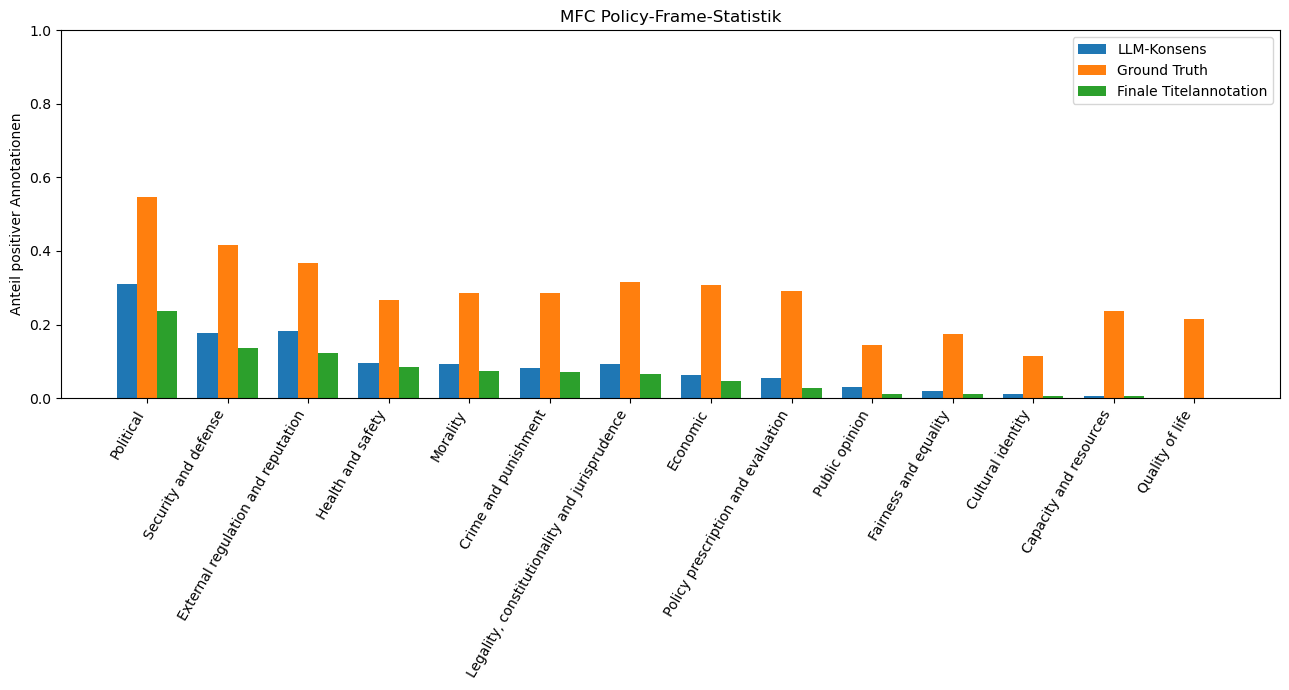

In [7]:
statistics_rows = []

for frame in FRAME_COLUMNS:
    row = {"Frame": frame}

    for model_name, df in zip(llm_names, llm_indexed):
        row[f"{model_name} positive"] = int(df[frame].sum())
        row[f"{model_name} Anteil"] = float(df[frame].mean())

    row["LLM-Konsens positive"] = int(consensus_binary[frame].sum())
    row["LLM-Konsens Anteil"] = float(consensus_binary[frame].mean())

    row["Ground Truth positive"] = int(gt_indexed[frame].sum())
    row["Ground Truth Anteil"] = float(gt_indexed[frame].mean())

    row["Finale Titelannotation positive"] = int(final_binary[frame].sum())
    row["Finale Titelannotation Anteil"] = float(final_binary[frame].mean())

    statistics_rows.append(row)

frame_statistics = pd.DataFrame(statistics_rows)
display(frame_statistics)

plot_df = frame_statistics[
    ["Frame", "LLM-Konsens Anteil", "Ground Truth Anteil", "Finale Titelannotation Anteil"]
].sort_values("Finale Titelannotation Anteil", ascending=False)

plt.figure(figsize=(13, 7))
x = np.arange(len(plot_df))
width = 0.25
plt.bar(x - width, plot_df["LLM-Konsens Anteil"], width, label="LLM-Konsens")
plt.bar(x, plot_df["Ground Truth Anteil"], width, label="Ground Truth")
plt.bar(x + width, plot_df["Finale Titelannotation Anteil"], width, label="Finale Titelannotation")
plt.xticks(x, plot_df["Frame"], rotation=60, ha="right")
plt.ylabel("Anteil positiver Annotationen")
plt.title("MFC Policy-Frame-Statistik")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FILES["plot"], dpi=200, bbox_inches="tight")
plt.show()


## 7. Zentrale Auswertung und Qualitätsbericht


In [8]:
agreement_counts = consensus_protocol["Übereinstimmung"].value_counts().to_dict()

summary_lines = [
    "MFC Policy-Frame-Titelannotation – zentrale Auswertung",
    "=" * 60,
    "",
    f"Artikel: {len(article_ids)}",
    f"LLM-Modelle: {LLM_COUNT}",
    "Konsensregel: mindestens 2 von 3 positiven Stimmen",
    "LLM-Umcodierung: 2 -> 1",
    "Ground Truth: mfc_ground_truth_full.csv",
    "",
    f"Konsensuelle positive Artikel-Frame-Paare: {consensus_pairs}",
    f"Davon 2/3: {agreement_counts.get('2/3', 0)}",
    f"Davon 3/3: {agreement_counts.get('3/3', 0)}",
    f"Nach Ground-Truth-Abgleich behalten: {kept_pairs}",
    f"Nach Ground-Truth-Abgleich gestrichen: {removed_pairs}",
    f"Metadatenabweichungen zwischen Dateien: {len(metadata_mismatches)}",
    "",
    "Finale positive Frames nach Frame:",
]

for frame in FRAME_COLUMNS:
    summary_lines.append(
        f"  - {frame}: {int(final_binary[frame].sum())}"
    )

summary_text = "\n".join(summary_lines) + "\n"
OUTPUT_FILES["summary"].write_text(summary_text, encoding="utf-8")
print(summary_text)


MFC Policy-Frame-Titelannotation – zentrale Auswertung

Artikel: 1401
LLM-Modelle: 3
Konsensregel: mindestens 2 von 3 positiven Stimmen
LLM-Umcodierung: 2 -> 1
Ground Truth: mfc_ground_truth_full.csv

Konsensuelle positive Artikel-Frame-Paare: 1704
Davon 2/3: 935
Davon 3/3: 769
Nach Ground-Truth-Abgleich behalten: 1258
Nach Ground-Truth-Abgleich gestrichen: 446
Metadatenabweichungen zwischen Dateien: 0

Finale positive Frames nach Frame:
  - Economic: 65
  - Capacity and resources: 6
  - Morality: 103
  - Fairness and equality: 15
  - Legality, constitutionality and jurisprudence: 91
  - Policy prescription and evaluation: 40
  - Crime and punishment: 99
  - Security and defense: 191
  - Health and safety: 119
  - Quality of life: 1
  - Cultural identity: 8
  - Public opinion: 17
  - Political: 333
  - External regulation and reputation: 170



## 8. Dateien speichern

Die Ausgabedateien erhalten die vereinbarten Namen mit `mfc_`-Präfix und werden ausschließlich im Unterordner `mfc_konsens_output` gespeichert.


In [9]:
# 01 – LLM-Konsens (breites Format)
consensus_wide.to_excel(OUTPUT_FILES["consensus"], index=False)

# 02 – vollständiges Konsensprotokoll
with pd.ExcelWriter(OUTPUT_FILES["protocol"], engine="openpyxl") as writer:
    consensus_protocol.to_excel(writer, sheet_name="Konsensprotokoll", index=False)
    agreement_summary.to_excel(writer, sheet_name="Übereinstimmung", index=False)
    id_report.to_excel(writer, sheet_name="ID_Prüfung", index=False)
    if not metadata_mismatches.empty:
        metadata_mismatches.to_excel(
            writer, sheet_name="Metadatenabweichungen", index=False
        )

# 03 – finale Titelannotation
final_title_annotations.to_excel(OUTPUT_FILES["final"], index=False)

# 04 – Streichungsprotokoll
with pd.ExcelWriter(OUTPUT_FILES["removal"], engine="openpyxl") as writer:
    removal_protocol.to_excel(
        writer, sheet_name="Streichungsprotokoll", index=False
    )
    removed_summary = (
        removal_protocol[removal_protocol["Behalten"] == 0]
        .groupby("Frame", as_index=False)
        .size()
        .rename(columns={"size": "Gestrichene_Paare"})
    )
    removed_summary.to_excel(writer, sheet_name="Nach_Frame", index=False)

# 05 – Frame-Statistik
frame_statistics.to_excel(OUTPUT_FILES["statistics"], index=False)

print("\nErzeugte Dateien:")
for path in OUTPUT_FILES.values():
    if path.exists():
        print(f" - {path.name} ({path.stat().st_size:,} Bytes)")

display(Markdown(f"**Ausgabeordner:** `{OUTPUT_DIR.resolve()}`"))



Erzeugte Dateien:
 - mfc_01_llm_konsens.xlsx (130,121 Bytes)
 - mfc_02_konsensprotokoll.xlsx (1,740,544 Bytes)
 - mfc_03_finale_titelannotationen.xlsx (129,393 Bytes)
 - mfc_04_streichungsprotokoll.xlsx (155,275 Bytes)
 - mfc_05_frame_statistik.xlsx (7,291 Bytes)
 - mfc_05_frame_statistik.png (236,087 Bytes)
 - mfc_06_zentrale_auswertung.txt (917 Bytes)


**Ausgabeordner:** `/Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_additional_dataset/5_konsens_bildung/semeval_2023/mfc_konsens_output`

## 9. Abschließende Integritätsprüfung


In [10]:
assert len(consensus_wide) == len(article_ids)
assert len(final_title_annotations) == len(article_ids)
assert set(final_title_annotations[ID_COLUMN]) == set(article_ids)
assert all(frame in final_title_annotations.columns for frame in FRAME_COLUMNS)
assert set(final_title_annotations[FRAME_COLUMNS].to_numpy().ravel()).issubset({0, 1})
assert all(path.exists() for path in OUTPUT_FILES.values())

print(f"✓ {len(article_ids):,} Artikel vorhanden")
print("✓ Filename-IDs in allen vier Dateien identisch und eindeutig")
print(f"✓ {len(FRAME_COLUMNS)} Frame-Spalten vorhanden")
print("✓ Finale Frame-Werte ausschließlich 0/1")
print("✓ Alle vereinbarten Ausgabedateien vorhanden")
print("\nWorkflow erfolgreich abgeschlossen.")


✓ 1,401 Artikel vorhanden
✓ Filename-IDs in allen vier Dateien identisch und eindeutig
✓ 14 Frame-Spalten vorhanden
✓ Finale Frame-Werte ausschließlich 0/1
✓ Alle vereinbarten Ausgabedateien vorhanden

Workflow erfolgreich abgeschlossen.
